In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
!pip install xgboost

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

In [4]:
# 데이터 로드
df = pd.read_csv('../data/insurance_policyholder_churn_synthetic.csv')
churn_df = df.copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   customer_id                  50000 non-null  int64  
 1   as_of_date                   50000 non-null  object 
 2   region_name                  50000 non-null  object 
 3   age                          50000 non-null  int64  
 4   age_band                     50000 non-null  object 
 5   marital_status               50000 non-null  object 
 6   customer_tenure_months       50000 non-null  int64  
 7   multi_policy_flag            50000 non-null  int64  
 8   num_policies                 50000 non-null  int64  
 9   policy_type                  50000 non-null  object 
 10  renewal_month                50000 non-null  int64  
 11  current_premium              50000 non-null  float64
 12  premium_last_year            50000 non-null  float64
 13  premium_change_p

### 1. 모델 학습(Base)

In [23]:
# 1. 데이터 준비 및 피처 엔지니어링 (가설 반영)
df_1 = churn_df.copy()

# EDA에서 확인한 변수 추가
df_1['is_rejected'] = (df_1['num_rejected_claims_12m'] > 0).astype(int)
df_1['unpaid_ratio'] = 1 - df_1['payout_ratio_12m']

# 2. 불필요한 컬럼 제거
drop_cols = ['customer_id', 'as_of_date', 'churn_type', 'churn_probability_true']
df_model = df_1.drop(columns=drop_cols, errors='ignore')

# 3. 범주형 변수(문자열) 처리
le = LabelEncoder()
for col in df_model.select_dtypes(include=['object']).columns:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

# 4. 학습/테스트 데이터 분리
X = df_model.drop(columns=['churn_flag'])
y = df_model['churn_flag']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 5. 모델학습
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=5,
    class_weight={0: 1, 1: 3},
    random_state=42
)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

=== [1단계: 베이스 모델] 성능 지표 ===
정확도(Accuracy): 0.6643
AUC 점수: 0.7855
F2-Score (Recall 가중): 0.6961

[상세 분류 리포트]
              precision    recall  f1-score   support

           0       0.87      0.61      0.72      6983
           1       0.47      0.79      0.59      3017

    accuracy                           0.66     10000
   macro avg       0.67      0.70      0.65     10000
weighted avg       0.75      0.66      0.68     10000



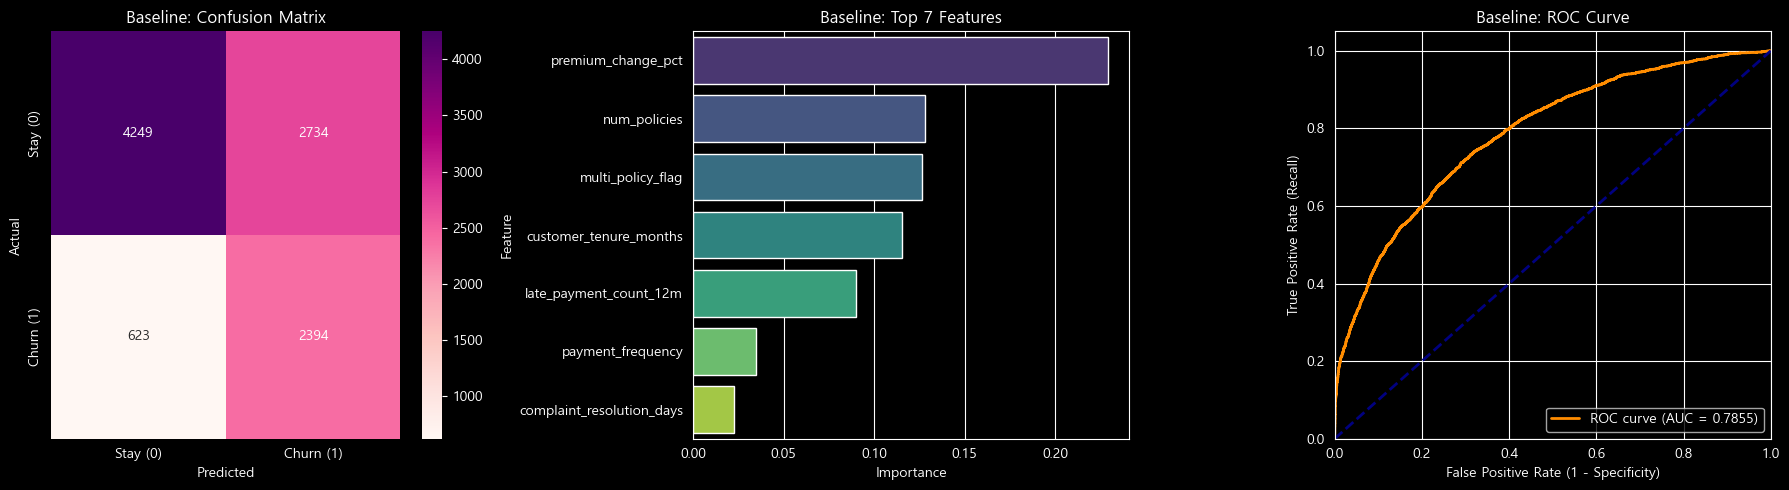


베이스라인 결과 해석:
- 실제 이탈자 3017명 중 2394명을 찾아냈습니다. (Recall: 0.79)
- AUC가 0.79라는 것은 모델이 두 집단을 분류할 확률적 능력이 우수함을 뜻합니다.


In [28]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score, accuracy_score
from sklearn.metrics import fbeta_score

# 1. 예측 및 확률값 계산
y_pred = model.predict(X_test)
y_probs = model.predict_proba(X_test)[:, 1] # 이탈(1)일 확률 추출

#  F2-score 계산 (이탈자(1)에 대한 가중치 평가)
f2 = fbeta_score(y_test, y_pred, beta=2.0)

# 2. 기본 지표 출력
print("=== [1단계: 베이스 모델] 성능 지표 ===")
print(f"정확도(Accuracy): {accuracy_score(y_test, y_pred):.4f}")
auc_score = roc_auc_score(y_test, y_probs)
print(f"AUC 점수: {auc_score:.4f}")
print(f"F2-Score (Recall 가중): {f2:.4f}")
print("\n[상세 분류 리포트]")
print(classification_report(y_test, y_pred))

# ---------------------------------------------------------
# 3. 시각화 (혼동행렬, 변수 중요도, ROC 커브)
# ---------------------------------------------------------
plt.figure(figsize=(18, 5))

# (1) 혼동행렬 (Confusion Matrix)
plt.subplot(1, 3, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu',
            xticklabels=['Stay (0)', 'Churn (1)'],
            yticklabels=['Stay (0)', 'Churn (1)'])
plt.title('Baseline: Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# (2) 변수 중요도 (Feature Importance)
plt.subplot(1, 3, 2)
importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False).head(7)

sns.barplot(data=importances, x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False)
plt.title('Baseline: Top 7 Features')

# (3) ROC 커브 (ROC Curve)
plt.subplot(1, 3, 3)
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # 기준선
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Baseline: ROC Curve')
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

# 수치 해석
tn, fp, fn, tp = cm.ravel()
print(f"\n베이스라인 결과 해석:")
print(f"- 실제 이탈자 {tp+fn}명 중 {tp}명을 찾아냈습니다. (Recall: {tp/(tp+fn):.2f})")
print(f"- AUC가 {auc_score:.2f}라는 것은 모델이 두 집단을 분류할 확률적 능력이 우수함을 뜻합니다.")

### 2. 하이퍼파라미터 튜닝

Fitting 3 folds for each of 36 candidates, totalling 108 fits
=== [Tuned Best Model] 성능 리포트 ===
최적 파라미터: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 100}
튜닝 후 정확도: 0.6641
튜닝 후 AUC 점수: 0.7842

[상세 분류 리포트]
              precision    recall  f1-score   support

           0       0.87      0.61      0.72      6983
           1       0.47      0.79      0.59      3017

    accuracy                           0.66     10000
   macro avg       0.67      0.70      0.65     10000
weighted avg       0.75      0.66      0.68     10000



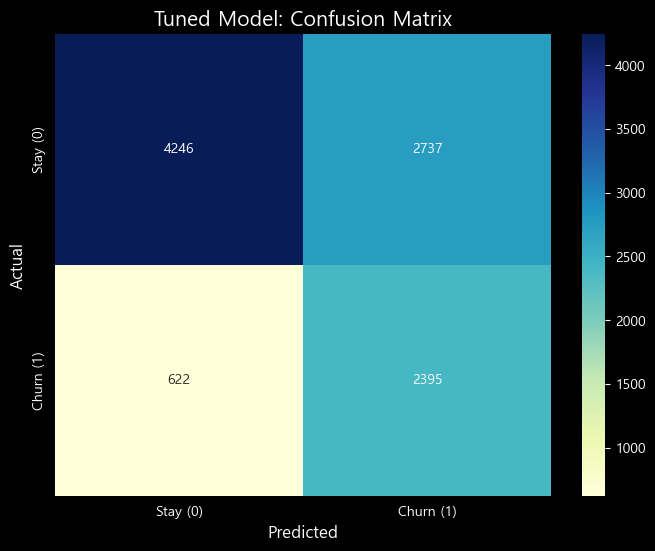

---------------------------------------------
유지(0)를 유지로 맞힘: 4246명
이탈(1)을 이탈로 맞힘: 2395명
이탈(1)인데 놓침(유지로 예측): 622명
유지(0)인데 이탈로 오해함: 2737명
---------------------------------------------


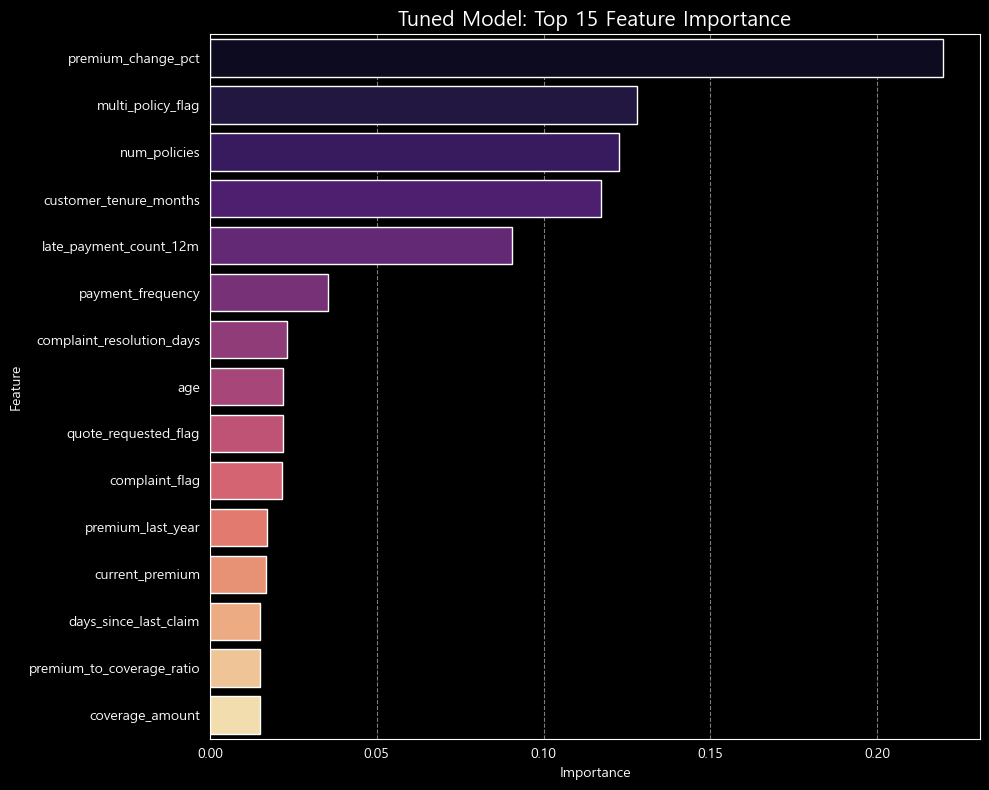

In [22]:
from sklearn.model_selection import GridSearchCV

# 1. Parameter Grid 설정
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, None],
    'min_samples_split': [2, 5, 10],    # 노드를 나누기 위한 최소 샘플 수
    'max_features': ['sqrt', 'log2']    # 최적의 분할을 위해 고려할 피처 수
}

# 2. 그리드 서치 설정 (평가 지표를 f1으로 설정하여 정확도와 리콜의 균형을 맞춤)
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(class_weight={0: 1, 1: 3}, random_state=42),
    param_grid=param_grid,
    cv=3,           # 3-Fold 교차 검증 (데이터를 3등분해서 돌려가며 학습)
    scoring='f1',   # 정확도와 리콜을 동시에 고려하는 f1-score 기준
    n_jobs=-1,      # 내 컴퓨터의 모든 CPU 사용 (속도 향상)
    verbose=1       # 진행 상황 출력
)

# 3. 최적의 조합 찾기 학습
grid_search.fit(X_train, y_train)

# 4. 최적의 모델 추출 및 평가
y_pred_best = best_model.predict(X_test)
y_probs_best = best_model.predict_proba(X_test)[:, 1]

print("=== [Tuned Best Model] 성능 리포트 ===")
print(f"최적 파라미터: {grid_search.best_params_}")
print(f"튜닝 후 정확도: {accuracy_score(y_test, y_pred_best):.4f}")
print(f"튜닝 후 AUC 점수: {roc_auc_score(y_test, y_probs_best):.4f}")
print("\n[상세 분류 리포트]")
print(classification_report(y_test, y_pred_best))

# ---------------------------------------------------------
# 5. 혼동행렬 (Confusion Matrix) 시각화
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))
cm_best = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm_best, annot=True, fmt='d', cmap='YlGnBu', # 튜닝 모델은 색상을 다르게 설정
            xticklabels=['Stay (0)', 'Churn (1)'],
            yticklabels=['Stay (0)', 'Churn (1)'])

plt.title('Tuned Model: Confusion Matrix', fontsize=15)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.show()

# ---------------------------------------------------------
# 6. 베이스라인 대비 수치 변화 확인
# ---------------------------------------------------------
tn_b, fp_b, fn_b, tp_b = cm_best.ravel()
print("-" * 45)
print(f"유지(0)를 유지로 맞힘: {tn_b}명")
print(f"이탈(1)을 이탈로 맞힘: {tp_b}명")
print(f"이탈(1)인데 놓침(유지로 예측): {fn_b}명")
print(f"유지(0)인데 이탈로 오해함: {fp_b}명")
print("-" * 45)

# ---------------------------------------------------------
# 7. 변수 중요도 (Feature Importance) 시각화
# ---------------------------------------------------------
# 최적 모델(best_model)의 중요도 추출
importances_best = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_model.feature_importances_
}).sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(10, 8))
sns.barplot(
    data=importances_best,
    x='Importance',
    y='Feature',
    hue='Feature',
    palette='magma', # 튜닝 모델은 강렬한 색상으로 시각화
    legend=False
)

plt.title('Tuned Model: Top 15 Feature Importance', fontsize=15)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### 3. 데이터 세분화 + 상생변수 추가해보기

청구 고객 전용 모델 정확도: 0.6754


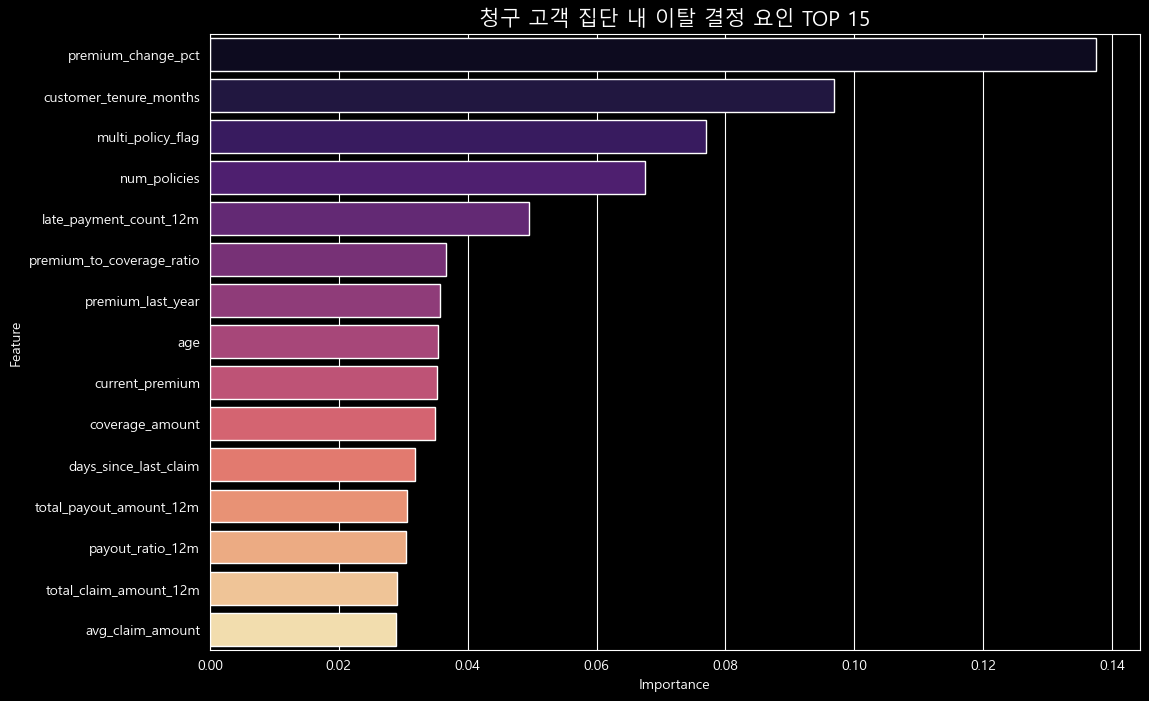

                      Feature  Importance
11         premium_change_pct    0.137442
4      customer_tenure_months    0.096830
5           multi_policy_flag    0.077041
6                num_policies    0.067510
17     late_payment_count_12m    0.049442
14  premium_to_coverage_ratio    0.036697
10          premium_last_year    0.035767
1                         age    0.035368
9             current_premium    0.035299
13            coverage_amount    0.034854
29      days_since_last_claim    0.031821
26    total_payout_amount_12m    0.030551
27           payout_ratio_12m    0.030408
25     total_claim_amount_12m    0.029069
24           avg_claim_amount    0.028833


In [12]:
# 1. 가설 집중형 데이터 세분화 (Segmentation)
# 최근 1년 내 보험금을 한 번이라도 청구한 고객만 추출
claims_only_df = churn_df[churn_df['num_claims_12m'] > 0].copy()

claims_only_df['is_rejected'] = (claims_only_df['num_rejected_claims_12m'] > 0).astype(int)  # 기존 변수

# 2. 상호작용 변수 생성 (Interaction Feature)
# 보험료 인상률(연속형)과 거절 여부(0 또는 1)를 곱해 새로운 변수 생성
# 가설: 보험료도 올랐는데 보상까지 거절당하면 이탈할 것이다
claims_only_df['anger_index'] = claims_only_df['premium_change_pct'] * claims_only_df['is_rejected']

# 3. 모델 재학습 (청구 고객 전용)
# 전처리 (ID 및 타겟 변수 제거)
drop_cols = ['customer_id', 'as_of_date', 'churn_type', 'churn_probability_true']
df_claims_model = claims_only_df.drop(columns=drop_cols, errors='ignore')

# 범주형 변수 인코딩
le = LabelEncoder()
for col in df_claims_model.select_dtypes(include=['object']).columns:
    df_claims_model[col] = le.fit_transform(df_claims_model[col].astype(str))

X_c = df_claims_model.drop(columns=['churn_flag'])
y_c = df_claims_model['churn_flag']

# 학습/테스트 분리
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_c, y_c, test_size=0.2, random_state=42, stratify=y_c)

# 모델 생성 (랜덤 포레스트)
model_claims = RandomForestClassifier(
    n_estimators=100, max_depth=10, class_weight={0: 1, 1: 3}, random_state=42
)
model_claims.fit(X_train_c, y_train_c)

# 4. 결과 확인 및 변수 중요도 시각화
print(f"청구 고객 전용 모델 정확도: {accuracy_score(y_test_c, model_claims.predict(X_test_c)):.4f}")

plt.figure(figsize=(12, 8))
importances_c = pd.DataFrame({'Feature': X_c.columns, 'Importance': model_claims.feature_importances_})
importances_c = importances_c.sort_values(by='Importance', ascending=False).head(15)

sns.barplot(data=importances_c, x='Importance', y='Feature', hue='Feature', palette='magma', legend=False)
plt.title('청구 고객 집단 내 이탈 결정 요인 TOP 15', fontsize=15)
plt.show()
print(importances_c)

In [13]:
# 상생변수 추가한 모델 지표 확인

# 1. 청구 고객 모델 예측 결과
y_pred_c = model_claims.predict(X_test_c)

# 2. 성능 지표 출력
print("=== [청구 고객 전용 모델] 성능 성적표 ===")
print(f"정확도 (Accuracy): {accuracy_score(y_test_c, y_pred_c):.4f}")
print("\n[상세 리포트]")
print(classification_report(y_test_c, y_pred_c))

# 3. 기존 모델과 비교 요약
from sklearn.metrics import recall_score, precision_score
print("-" * 35)
print(f"현재 모델 Recall (이탈자 포착 능력): {recall_score(y_test_c, y_pred_c):.4f}")
print(f"현재 모델 Precision (예측 정확도): {precision_score(y_test_c, y_pred_c):.4f}")

=== [청구 고객 전용 모델] 성능 성적표 ===
정확도 (Accuracy): 0.6754

[상세 리포트]
              precision    recall  f1-score   support

           0       0.82      0.65      0.73       891
           1       0.51      0.72      0.60       446

    accuracy                           0.68      1337
   macro avg       0.67      0.69      0.66      1337
weighted avg       0.72      0.68      0.68      1337

-----------------------------------
현재 모델 Recall (이탈자 포착 능력): 0.7175
현재 모델 Precision (예측 정확도): 0.5096


### 4. 임계값 조정으로 지표 상승 확인해보기 -> 정확도 너무 떨어짐

In [14]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. 테스트 데이터에 대해 '확률' 예측 (0 또는 1이 아닌 0~1 사이 값)
y_probs_c = model_claims.predict_proba(X_test_c)[:, 1]

# 2. Recall과 Accuracy의 균형을 찾기 위한 임계값(Threshold) 설정 (기존 0.5 -> 0.35 ~ 0.45로 조정)
custom_threshold = 0.4
y_pred_tuned = (y_probs_c >= custom_threshold).astype(int)

# 3. 결과 출력
print(f"[임계값 {custom_threshold} 적용 결과]")
print(f"정확도(Accuracy): {accuracy_score(y_test_c, y_pred_tuned):.4f}")
print("-" * 30)
print(classification_report(y_test_c, y_pred_tuned))

[임계값 0.4 적용 결과]
정확도(Accuracy): 0.5864
------------------------------
              precision    recall  f1-score   support

           0       0.86      0.45      0.59       891
           1       0.44      0.86      0.58       446

    accuracy                           0.59      1337
   macro avg       0.65      0.65      0.59      1337
weighted avg       0.72      0.59      0.59      1337



### 5. XGBoost로 돌려보기

가설 변수 중심 XGBoost 결과] 임계값 0.43 적용
정확도(Accuracy): 0.6196
---------------------------------------------
              precision    recall  f1-score   support

           0       0.89      0.52      0.65      6983
           1       0.43      0.86      0.58      3017

    accuracy                           0.62     10000
   macro avg       0.66      0.69      0.62     10000
weighted avg       0.75      0.62      0.63     10000



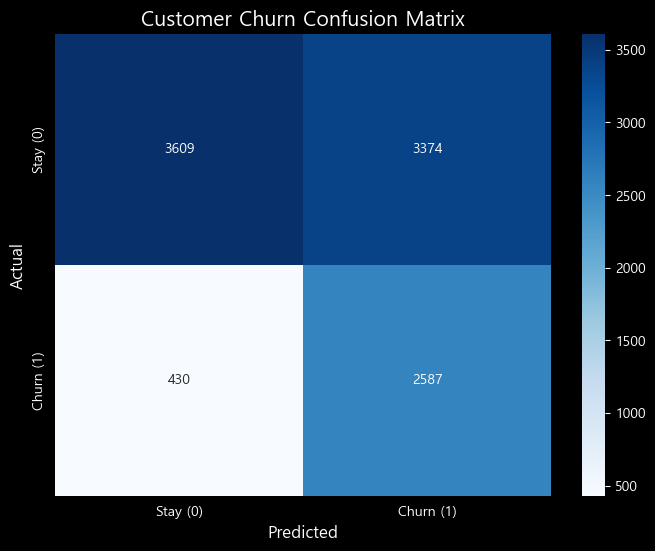

실제 유지 고객을 유지로 맞힘 (TN): 3609명
실제 이탈 고객을 이탈로 맞힘 (TP): 2587명
실제 이탈인데 유지로 놓침 (FN): 430명 (Recall과 직결!)
실제 유지인데 이탈로 오해함 (FP): 3374명 (Precision과 직결!)

변수 중요도 TOP 10 (anger_index 순위 확인)
                    Feature  Importance
5         multi_policy_flag    0.322239
11       premium_change_pct    0.086147
31           complaint_flag    0.082308
17   late_payment_count_12m    0.070119
4    customer_tenure_months    0.053210
15        payment_frequency    0.048690
33     quote_requested_flag    0.038604
27         payout_ratio_12m    0.033099
22  num_rejected_claims_12m    0.027728
34  coverage_downgrade_flag    0.024172


In [16]:
# 1. XGBoost 모델 설정
# 가중치(scale_pos_weight)를 3.0으로 주어 이탈자 포착(Recall)에 집중
xgb_initial = XGBClassifier(
    n_estimators=500,
    learning_rate=0.01,
    max_depth=6,
    scale_pos_weight=3.0,
    random_state=42,
    eval_metric='logloss'
)

# 2. 학습 진행 (현재 X_train에 있는 'anger_index'의 영향력을 순수하게 확인)
xgb_initial.fit(X_train, y_train)

# 3. 결과 예측 및 임계값 적용
# 확률값을 뽑은 뒤, 0.44 임계값을 적용
y_probs = xgb_initial.predict_proba(X_test)[:, 1]
custom_threshold = 0.43
y_pred = (y_probs >= custom_threshold).astype(int)

# 4. 성능 지표 출력
print(f"가설 변수 중심 XGBoost 결과] 임계값 {custom_threshold} 적용")
print(f"정확도(Accuracy): {accuracy_score(y_test, y_pred):.4f}")
print("-" * 45)
print(classification_report(y_test, y_pred))

# 5. 혼동행렬 계산
cm = confusion_matrix(y_test, y_pred)

# 6. 시각화 (Heatmap)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stay (0)', 'Churn (1)'],
            yticklabels=['Stay (0)', 'Churn (1)'])

plt.title('Customer Churn Confusion Matrix', fontsize=15)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.show()

# 7. 수치 해석 출력
tn, fp, fn, tp = cm.ravel()
print(f"실제 유지 고객을 유지로 맞힘 (TN): {tn}명")
print(f"실제 이탈 고객을 이탈로 맞힘 (TP): {tp}명")
print(f"실제 이탈인데 유지로 놓침 (FN): {fn}명 (Recall과 직결!)")
print(f"실제 유지인데 이탈로 오해함 (FP): {fp}명 (Precision과 직결!)")

# 8. 변수 중요도(Feature Importance) 확인
importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_initial.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n변수 중요도 TOP 10 (anger_index 순위 확인)")
print(importances.head(10))

1️⃣ Baseline 모델 구축
내용: 전체 변수를 활용하여 랜덤 포레스트 기본 모델 학습.

결과: 보상 관련 변수들이 이탈 예측에 큰 힘을 쓰지 못하는 초기 상태 확인.

2️⃣ 하이퍼파라미터 튜닝
내용: 모델 자체의 성능을 높이기 위해 max_depth 등 최적화 시도.

결과: 도구의 설정값 변경만으로는 지표의 유의미한 상승을 이끌어내기 어려움 확인.

3️⃣ 상생 가설 기반 변수 생성 (가설 설정)
내용: "보상 거절 경험(is_rejected)이 보험료 인상(premium_change_pct)과 결합될 때 이탈에 결정적일 것"이라는 상생 변수(anger_index) 수립 및 투입.

4️⃣ 임계값(Threshold) 조정 (한계 확인)
내용: 이탈자 포착(Recall)을 강제로 높이기 위해 판단 기준선 조정.

결과: 재현율은 올랐으나 정확도가 0.5대로 급락하며, 현재 변수들만으로는 이탈자와 유지자의 경계가 모호함을 발견.

5️⃣ 피처 엔지니어링 및 가설 검증 (반전)
내용: 모델의 판단력을 높이기 위해 premium_shock, payout_efficiency 등 정교한 수치 변수 추가.

결과: 직접 만든 상생 변수는 중요도 상위에 오르지 못함. 대신 데이터는 premium_shock(가입 기간 대비 인상폭)를 가장 강력한 원인으로 지목함.

6️⃣ 알고리즘 고도화 및 데이터 재해석 (XGBoost)
내용: XGBoost로 교체하여 premium_shock의 패턴을 학습.

최종 결론: 내 가설(거절 경험)보다 **데이터가 가리키는 현상(가입 기간 대비 급격한 가격 인상)**이 이탈의 더 실질적인 '방점'이었음을 확인.